# Domain shift TDV
```Authors: Paul Alvarez updated: 20261609```


El presente notebook explora el efecto del cambio de dominio (respecto al entrenamiento, en base al dataset BSDS400, que contiene imágenes naturales) en el rendimiento del algoritmo Total Deep Variation (TDV) propuesto por Kobler et. al. Dentro de ello, se analizarán el efecto de imágenes lineales v/s no lineas, y en concreto, muestras astronómicas de diverso tipo (estelares, no estelares, etc).

## Setup

In [3]:
import sys
import os
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path: sys.path.append(root_path)

In [5]:
# requeriments
import imageio.v2 as imageio
import numpy as np
import matplotlib.pyplot as plt
from tdv.denoise_utils import apply_vn, check_color, denoise_z, load_model, psnr, test_img
from skimage.metrics import structural_similarity as ssim
from notebooks.utils import plot_results
from skimage import data, img_as_float
from astropy.io import fits

## Real noise 

In [55]:
# load tif
tif = 'm20_greennoise_G.tif'
img_path = os.path.join('..', 'data', tif)
img_raw = imageio.imread(img_path)
img_norm = img_as_float(img_raw).astype(np.float32)

_, color = check_color(img_norm)

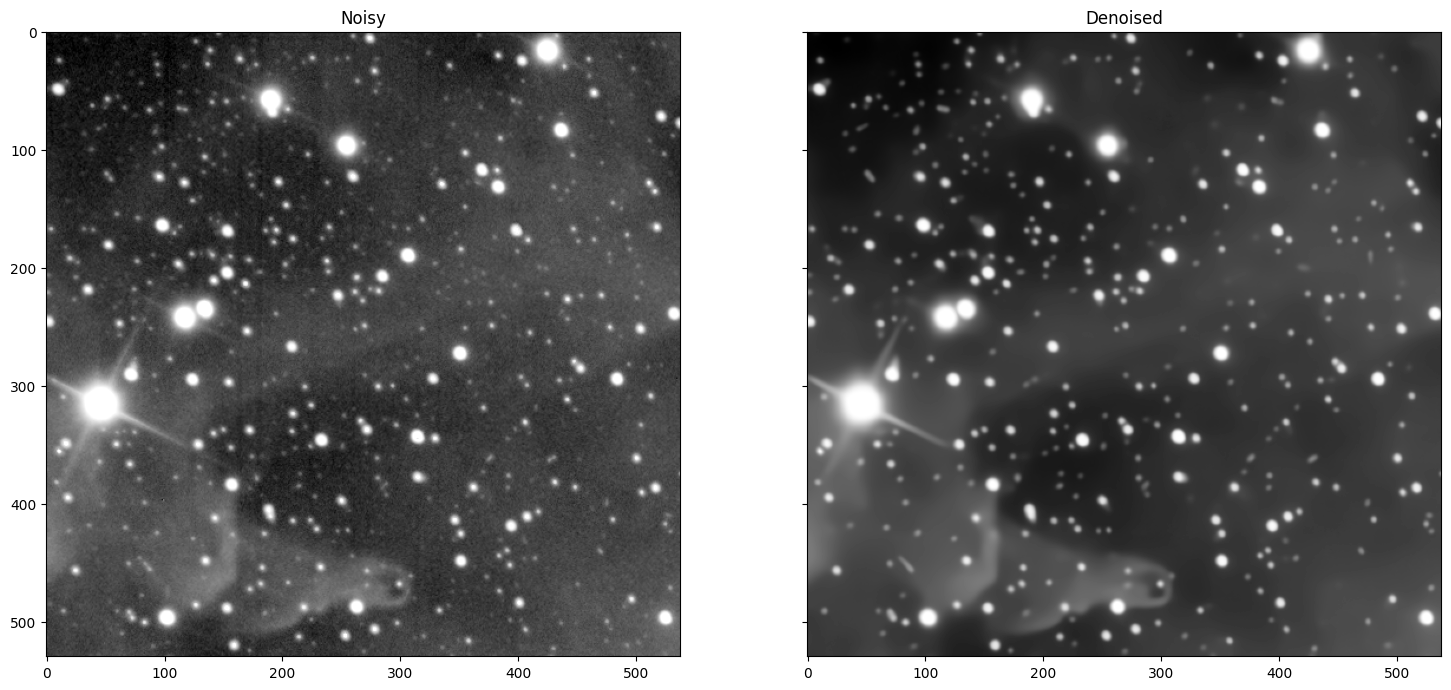

In [44]:
# See  with TDV
vn, _ = load_model(color) # gray ?

z, x_S, _ = test_img(vn, img=img_norm, add_noise=False)
plot_results(z, x_S, figsize=(18, 12))

In [62]:
def minimax_norm(img_raw):
    # apply minimax norm
    max_v = img_raw.max()
    min_v = img_raw.min()
    scale = max_v - min_v

    norm_img = (img_raw - min_v) / scale
    return norm_img
    

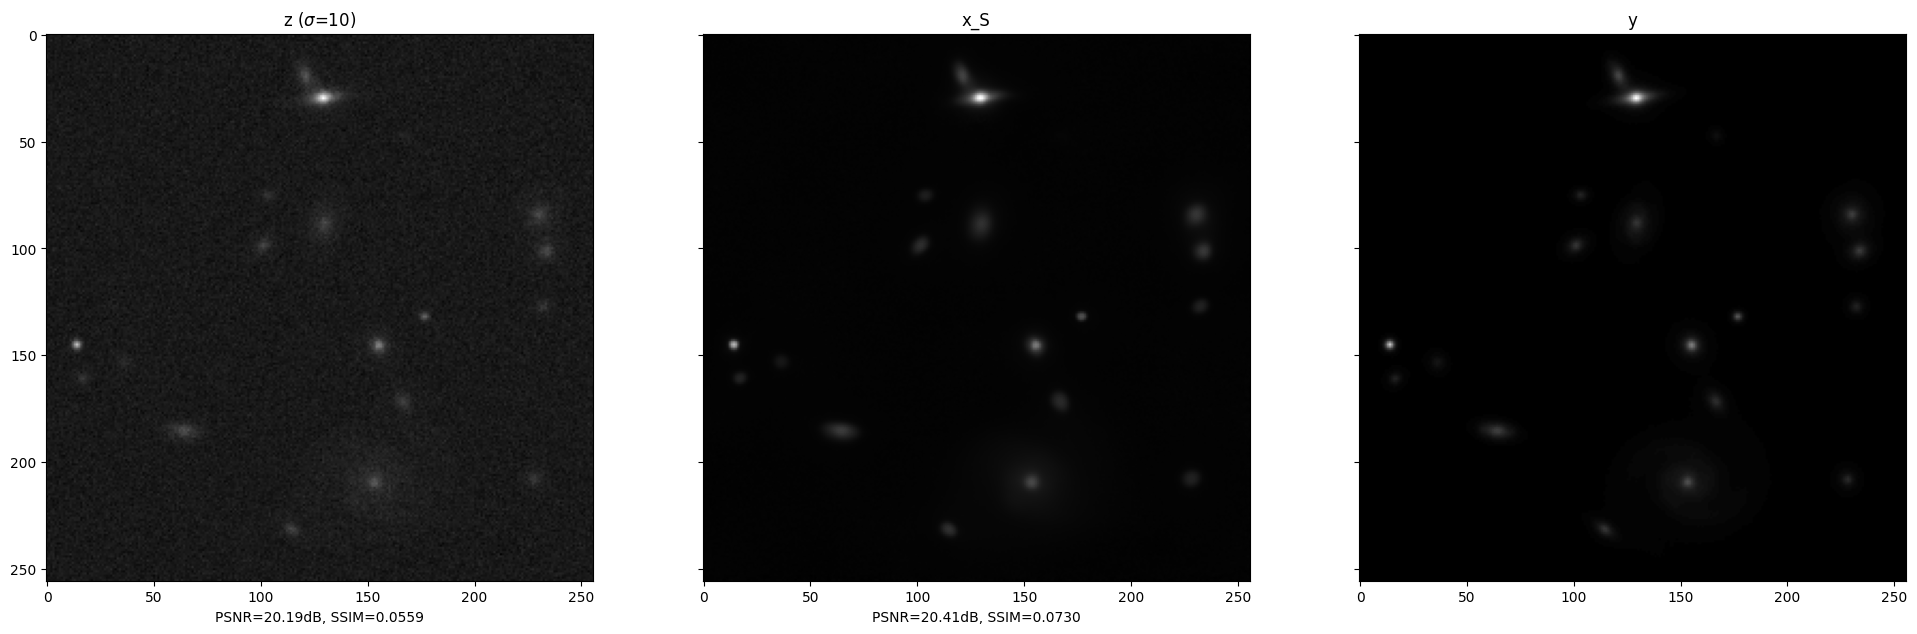

In [78]:
# load simulated .fits and normalize
fits_sim = "bert_orig.fits"
fits_sim_noisy = "bert_imag_g10.fits"
sigma = 10

img_path1 = os.path.join('..', 'data', fits_sim)
img_raw1 = img_as_float(fits.getdata(img_path1, ext=0)).astype(np.float32)

img_path2 = os.path.join('..', 'data', fits_sim_noisy)
img_raw2 = img_as_float(fits.getdata(img_path2, ext=0)).astype(np.float32)

y = minimax_norm(img_raw1)
z = minimax_norm(img_raw2)

# load tdv
y, color = check_color(y)
z, _ = check_color(z)
vn, _ = load_model(color) 

x = denoise_z(vn= vn, z=z, sigma= sigma, scaled=True)
plot_results(z, x, y, sigma= sigma, figsize=(24, 14))


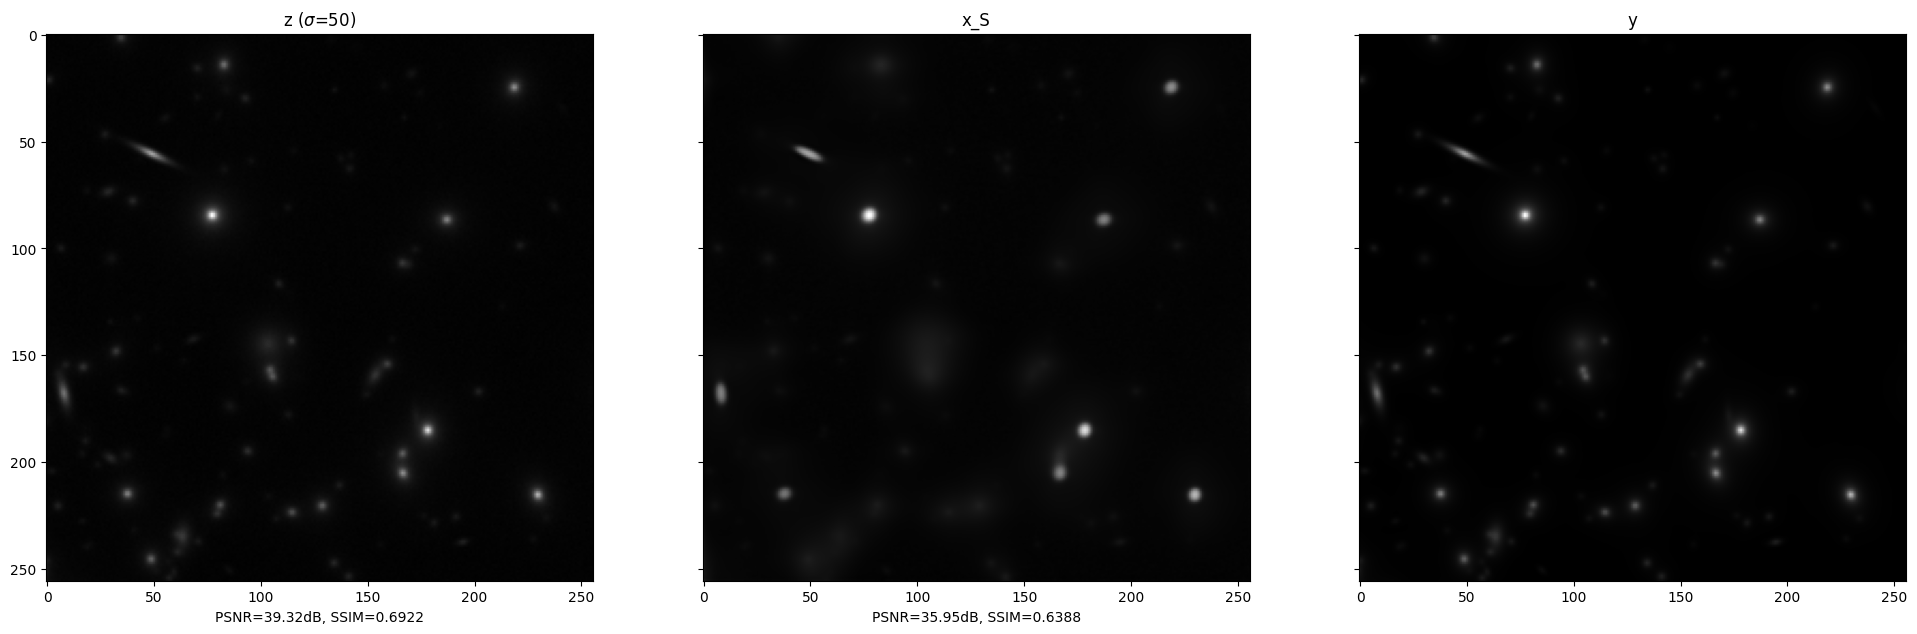

In [ ]:
# Simulated HST image + same img with gaussian noise (50 desv)
fits_sim = "simu_sky.fits"
fits_sim_noisy = "simu_gauss50.fits"
sigma = 50

img_path1 = os.path.join('..', 'data', fits_sim)
img_raw1 = img_as_float(fits.getdata(img_path1, ext=0)).astype(np.float32)

img_path2 = os.path.join('..', 'data', fits_sim_noisy)
img_raw2 = img_as_float(fits.getdata(img_path2, ext=0)).astype(np.float32)

y = minimax_norm(img_raw1)
z = minimax_norm(img_raw2)

# load tdv
y, color = check_color(y)
z, _ = check_color(z)
vn, _ = load_model(color) 

x = denoise_z(vn= vn, z=z, sigma= sigma, scaled=True)
plot_results(z, x, y, sigma= sigma, figsize=(24, 14))


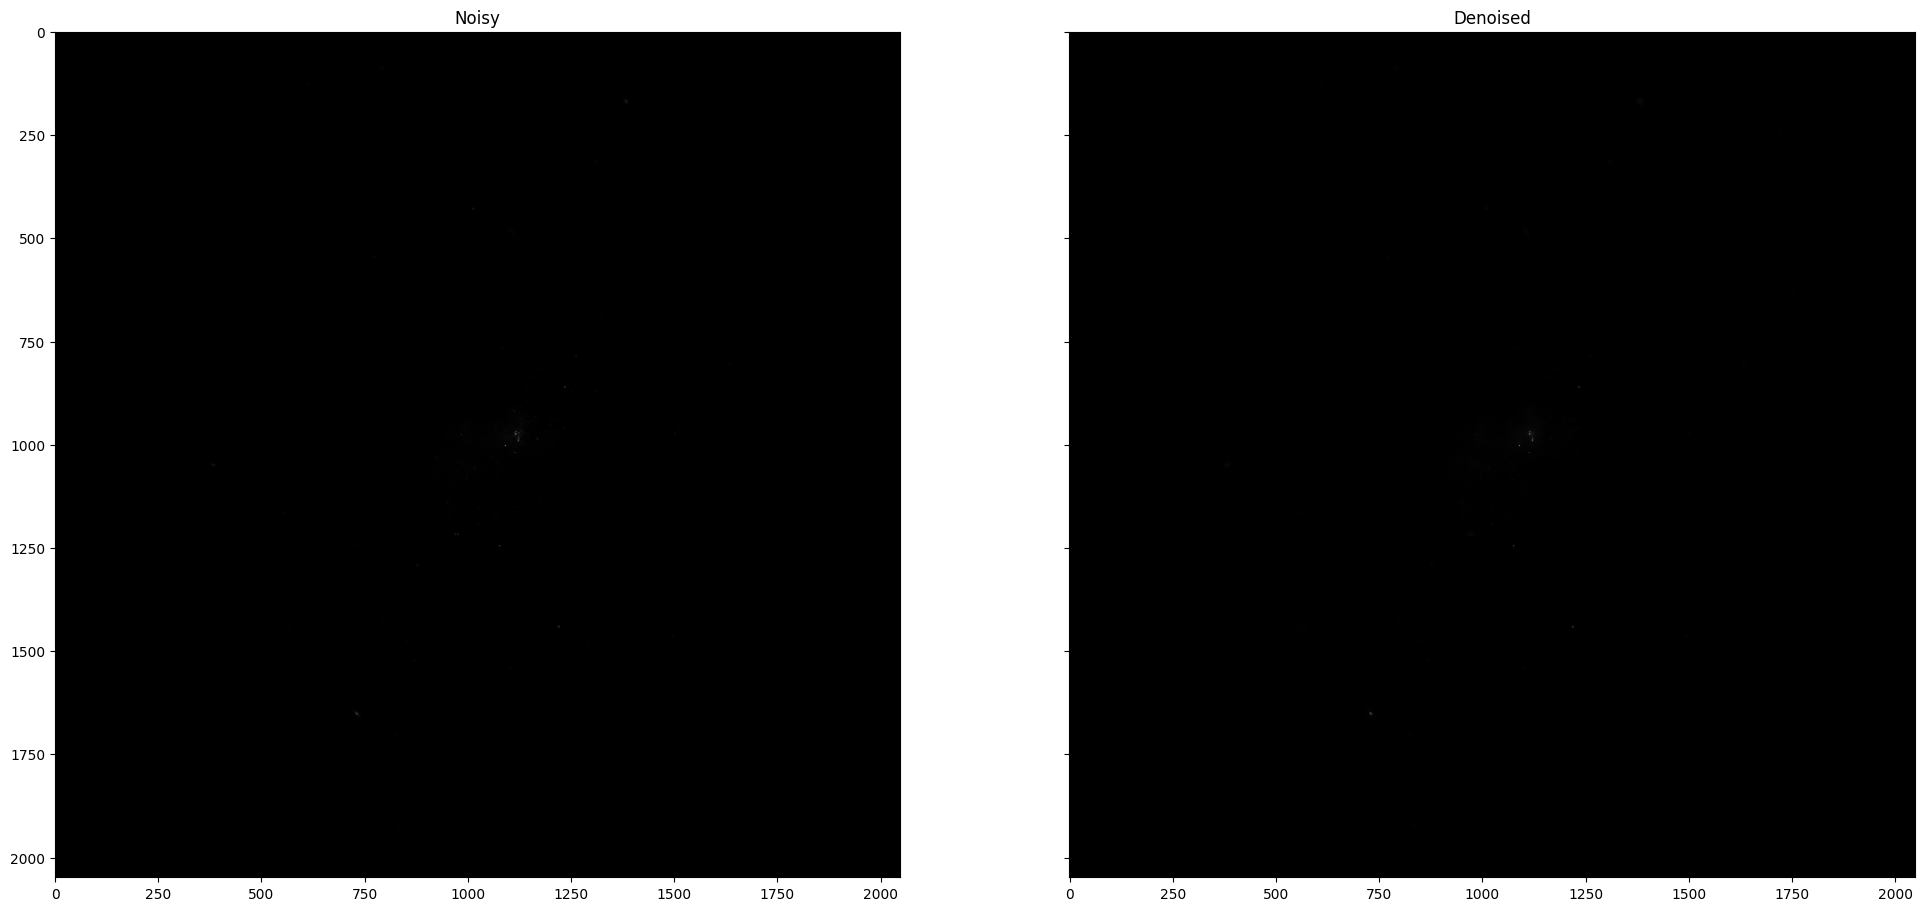

In [79]:
# Simulated HST image + same img with gaussian noise (50 desv)
fits_sim_noisy = "sgra_hires.fits"
img_path2 = os.path.join('..', 'data', fits_sim_noisy)
img_raw2 = img_as_float(fits.getdata(img_path2, ext=0)).astype(np.float32)

z = minimax_norm(img_raw2)

# load tdv
z, _ = check_color(z)
vn, _ = load_model(color) 

x = denoise_z(vn= vn, z=z, scaled=False)
plot_results(z, x, figsize=(24, 14))

In [80]:
def plot_results(z, x_S, y=None, sigma=None, peak=None, prob= None, figsize= (18, 12)):

    """
    z: noisy image
    x_S: denoised image
    y: ground truth
    """

    z, x_S = np.squeeze(z), np.squeeze(x_S)
    y = np.squeeze(y) if y is not None else None

    c_axis = -1 if z.ndim == 3 else None
    cmap = 'gray' if z.ndim == 2 else None

    if y is not None:

        fig, ax = plt.subplots(1, 3, sharex=True, sharey=True, figsize=figsize)

        ax[0].imshow(np.clip(z, 0, 1), cmap=cmap)
        if sigma is not None: ax[0].set_title(rf'z ($\sigma$={sigma})')
        if peak is not None: ax[0].set_title(rf'z ($peak$={peak})')
        if prob is not None: ax[0].set_title(rf'z ($salt pepper$={prob})')
        if peak and sigma is not None: ax[0].set_title(rf'z ($\sigma$={sigma}, $peak$={peak})')
        if sigma is None and peak is None and prob is None: ax[0].set_title(rf'z')
        ax[0].set_xlabel(f'PSNR={psnr(z,y):.2f}dB, 'f'SSIM={ssim(z,y,data_range=1,channel_axis=c_axis):.4f}')
        ax[1].imshow(np.clip(x_S, 0, 1), cmap=cmap)
        ax[1].set_title('x_S')
        ax[1].set_xlabel(f'PSNR={psnr(x_S,y):.2f}dB, 'f'SSIM={ssim(x_S,y,data_range=1,channel_axis=c_axis):.4f}')
        ax[2].imshow(np.clip(y, 0, 1), cmap=cmap)
        ax[2].set_title('y')

    else:

        fig, ax = plt.subplots(1, 2, sharex=True, sharey=True, figsize=figsize)

        ax[0].imshow(np.clip(z, 0, 1), cmap=cmap)
        ax[0].set_title('Noisy')
        ax[1].imshow(np.clip(x_S, 0, 1), cmap=cmap)
        ax[1].set_title('Denoised')

    plt.show()


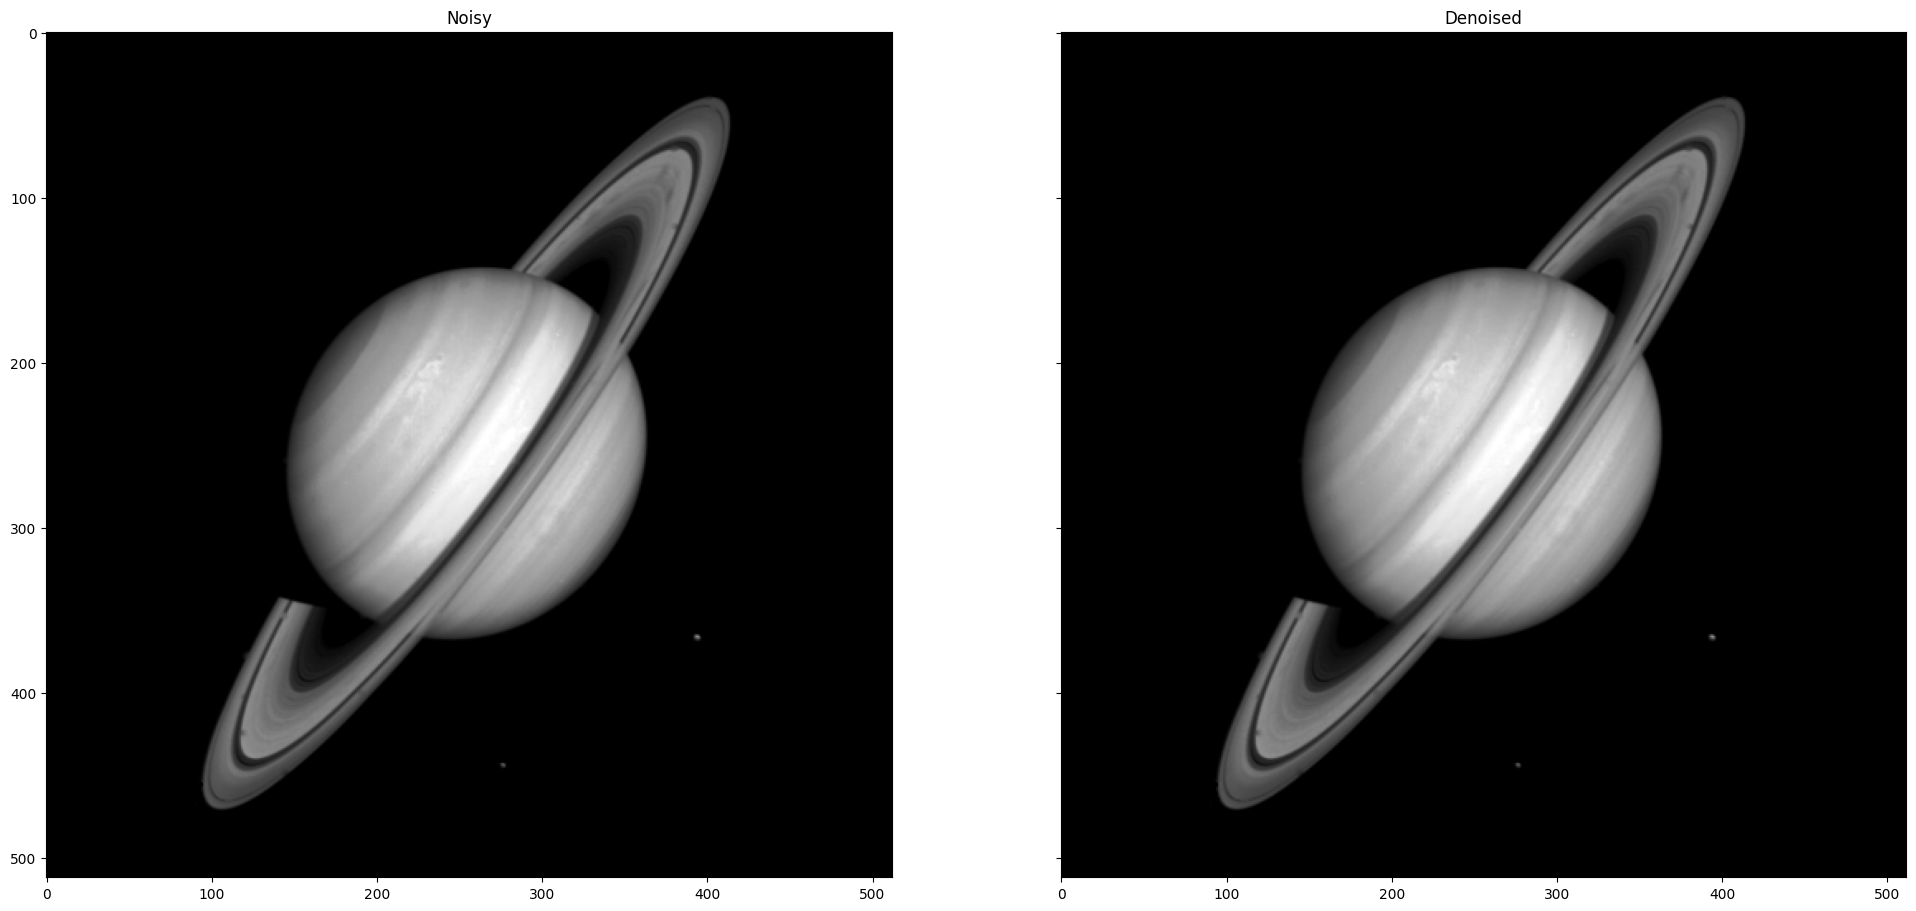

In [81]:
# Simulated HST image + same img with gaussian noise (50 desv)
fits_sim_noisy = "saturn512.fits"
img_path2 = os.path.join('..', 'data', fits_sim_noisy)
img_raw2 = img_as_float(fits.getdata(img_path2, ext=0)).astype(np.float32)

z_maxnorm = img_raw2 / img_raw2.max()
z_minimax = minimax_norm(img_raw2)

# load tdv
#z, _ = check_color(z)
#vn, _ = load_model(color) 

#x = denoise_z(vn= vn, z=z, scaled=False)
plot_results(z_maxnorm, z_minimax, figsize=(24, 14))